Libary

In [2]:
import numpy as np
import pandas as pd

Import Data

In [3]:
df = pd.read_csv(".\\news.csv")
df.head(15)

,text,category
0,The national football team won a friendly matc...,0
1,The new player signed his contract with the club,0
2,The Asian volleyball championship has begun,0
3,The team won the championship title this season,0
4,The national wrestling coach resigned from his...,0
5,The runner broke the national sprint record,0
6,The basketball team qualified for the world ch...,0
7,The football cup final will be held this week,0
8,The athlete won a gold medal at the Olympics,0
9,The national volleyball team started training ...,0


In [4]:
x = df["text"]
y = df["category"]

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
v = TfidfVectorizer()
x = v.fit_transform(x)
y = np.array(y)

In [6]:
x.shape , y.shape

((30, 140), (30,))

In [7]:
from sklearn.model_selection import train_test_split as tts
X_train , X_test , Y_train , Y_test = tts(x , y , test_size=0.2)

# Model

In [8]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(
    n_neighbors=3,
    leaf_size=70
)
model.fit(X_train , Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",70
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


# Rating

In [9]:
from sklearn.metrics import  confusion_matrix , accuracy_score
Y_pred = model.predict(X_test)
Y_pred_train = model.predict(X_train)

c = confusion_matrix(Y_test ,Y_pred)
a_test = accuracy_score(Y_test , Y_pred)
a_train = accuracy_score(Y_train , Y_pred_train)
print (f"\nConfusion : {c}\nAccuracy_Score_Train : {a_train}\nAccuracy_Score_Test : {a_test} ")


Confusion : [[2 0 0]
 [0 1 0]
 [1 0 2]]
Accuracy_Score_Train : 0.8333333333333334
Accuracy_Score_Test : 0.8333333333333334 


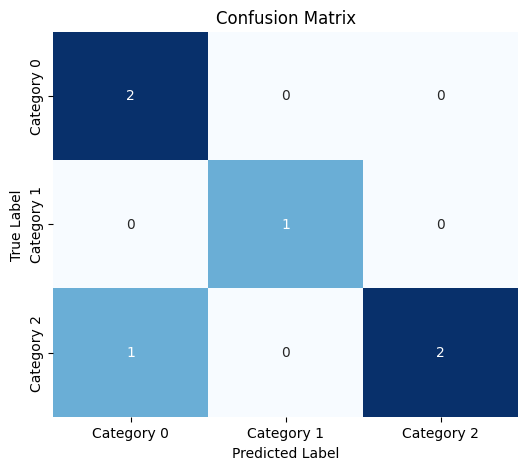

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(c, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Category 0', 'Category 1', 'Category 2'],
            yticklabels=['Category 0', 'Category 1', 'Category 2'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

C:\Users\mahan.ly\AppData\Local\Temp\ipykernel_6264\57945124.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette='viridis')


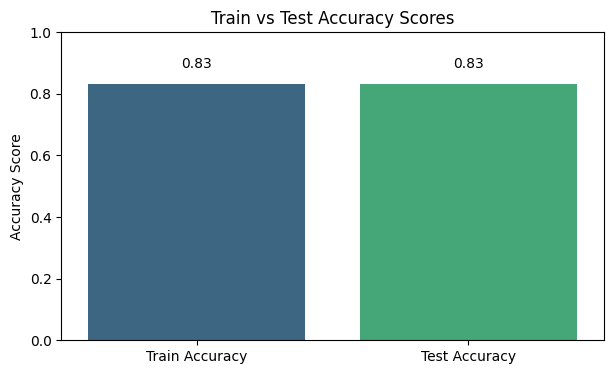

In [12]:
accuracy_scores = {'Train Accuracy': a_train, 'Test Accuracy': a_test}
labels = list(accuracy_scores.keys())
values = list(accuracy_scores.values())

plt.figure(figsize=(7, 4))
sns.barplot(x=labels, y=values, palette='viridis')
plt.title('Train vs Test Accuracy Scores')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1) # Accuracy scores are between 0 and 1
for index, value in enumerate(values):
    plt.text(index, value + 0.05, f'{value:.2f}', color='black', ha="center")
plt.show()

# Predict

In [11]:
x_new = ["The dollar exchange rate rose in the open market"]
x_new_result = v.transform(x_new)
result = model.predict(x_new_result)
if result == [0]:
    print("Sports")
elif result == [1]:
    print("Politics")
elif result == [2]:
    print("Economics")

Economics
